# HealthConnect Clinic — Week 7: Analytical Testing, KPI Validation & Dashboard Refinement
**Data Analytics Track | AnalystLab Africa Experience Lab | Moses Oluwatosin | 16 September 2026**

Week 7 does not repeat the Week 5 EDA or rebuild the Week 6 dashboard. It puts the Week 6 outputs
under test, finds where they fail, fixes them, re-tests, and reissues the corrected cross-track
artefact to the Data Science track.

**Headline result of this notebook:** every Week 6 number reproduces exactly — there is no coding
slip — but the Week 6 significance tests were run against the wrong outcome variable. Correcting
that changes every published effect size and reverses one recommendation that had already been
handed to the Data Science track.

## 1. Week 6 → Week 7 Transition

| | |
|---|---|
| **Main Week 6 output** | Advanced Analytics & Decision Support report, a 4-panel statistically-annotated dashboard, and `HealthConnect_Week6_Feature_Relevance.csv` |
| **Most important Week 6 result** | Booking lead time, prior no-show history, reminders and reminder channel are all statistically significant; appointment type is not; the reminder × history interaction is unconfirmed |
| **Main limitation carried in** | Findings remain observational; interaction test possibly underpowered; Sunday-appointment and missing-data items unresolved |
| **Component requiring testing** | The five chi-square tests, the KPI definitions, the dashboard, and the feature-relevance artefact already delivered to Data Science |
| **Tracks relevant this week** | **Data Science** (consumer of the artefact) and **Project Management** (issue log, KPI definition change) |
| **What I intend to test** | Whether the Week 6 statistics are reproducible, correctly specified, robust to segmentation, and honestly communicated by the dashboard |
| **What I expect to validate or improve** | Either confirm the Week 6 conclusions stand, or correct them before they propagate into the Week 8 model and clinic recommendations |

## 2. Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency, chi2 as chi2dist
from statsmodels.stats.multitest import multipletests

pd.set_option('display.max_columns', None); pd.set_option('display.width', 160)
plt.rcParams['figure.dpi'] = 110
NAVY, TEAL, GREY, GOLD, RED = '#1F3864', '#2E7D6B', '#8C8C8C', '#C9A227', '#B3261E'

df = pd.read_csv('../data/HealthConnect_Appointment_Data.csv')
df['booking_date'] = pd.to_datetime(df['booking_date'], format='%m/%d/%Y')
df['appointment_date'] = pd.to_datetime(df['appointment_date'], format='%m/%d/%Y')
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)
df['reminder_binary'] = (df['reminder_sent'] == 'Yes').astype(int)
df['lead_time_group'] = pd.cut(df['booking_lead_days'], bins=[-1,7,14,30,45,60,np.inf],
    labels=['0-7 days','8-14 days','15-30 days','31-45 days','46-60 days','61+ days']).cat.remove_unused_categories()
df['previous_no_show_group'] = pd.cut(df['previous_no_shows'], bins=[-1,0,1,np.inf],
    labels=['0 previous no-shows','1 previous no-show','2+ previous no-shows'])
df['channel_group'] = df['reminder_channel'].fillna('No Reminder')
print(f'Loaded {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded 5,000 rows x 23 columns


## 3. Test T1 — Data-integrity re-validation of the KPI inputs

**Objective:** before questioning any statistic, confirm the fields the statistics are built on are
internally consistent. A Week 6 conclusion cannot be trusted if `booking_lead_days` does not equal
the gap between the two date columns.

In [2]:
checks = {
 'booking_lead_days = appointment_date - booking_date':
     int(((df.appointment_date - df.booking_date).dt.days != df.booking_lead_days).sum()),
 'appointment_day matches appointment_date weekday':
     int((df.appointment_date.dt.day_name() != df.appointment_day).sum()),
 'no negative lead times': int((df.booking_lead_days < 0).sum()),
 'no duplicate appointment_id': int(df.appointment_id.duplicated().sum()),
 'previous_no_shows <= previous_appointments': int((df.previous_no_shows > df.previous_appointments).sum()),
 'reminder_channel null whenever reminder_sent = Yes':
     int(((df.reminder_channel.isna()) & (df.reminder_sent == 'Yes')).sum()),
 'reminder_channel present whenever reminder_sent = No':
     int(((df.reminder_channel.notna()) & (df.reminder_sent == 'No')).sum()),
}
for k, v in checks.items():
    print(f'{"PASS" if v == 0 else "FAIL"}  {k:<55} violations = {v}')

PASS  booking_lead_days = appointment_date - booking_date     violations = 0
PASS  appointment_day matches appointment_date weekday        violations = 0
PASS  no negative lead times                                  violations = 0
PASS  no duplicate appointment_id                             violations = 0
PASS  previous_no_shows <= previous_appointments              violations = 0
PASS  reminder_channel null whenever reminder_sent = Yes      violations = 0
PASS  reminder_channel present whenever reminder_sent = No    violations = 0


**T1 result: PASS on all seven checks.** Documented as a successful validation rather than
manufacturing an issue. One useful confirmation: all 1,366 null `reminder_channel` values correspond
exactly to `reminder_sent = 'No'`, so Week 6's decision to recode them as a `'No Reminder'` category
was correct and is not hiding missing data.

## 4. Test T2 — KPI reproduction and denominator review

**Objective:** do the three published Week 6 KPIs reproduce, and is the denominator right?

In [3]:
w6 = pd.Series({
    'No-Show Rate':      100*(df.appointment_outcome == 'No-Show').mean(),
    'Attendance Rate':   100*(df.appointment_outcome == 'Attended').mean(),
    'Cancellation Rate': 100*(df.appointment_outcome == 'Cancelled').mean()}).round(2)
print('Week 6 published: 48.5% / 46.3% / 5.3%')
print(w6.to_string())

att = df[df.appointment_outcome != 'Cancelled'].copy()   # Week 7 analysis base
print(f'\nDecided-appointment base (cancellations excluded): n = {len(att):,}')
print(f'No-show rate on that base:    {100*att.is_no_show.mean():.2f}%')
print(f'Attendance rate on that base: {100*(1-att.is_no_show.mean()):.2f}%')

Week 6 published: 48.5% / 46.3% / 5.3%
No-Show Rate         48.46
Attendance Rate      46.28
Cancellation Rate     5.26

Decided-appointment base (cancellations excluded): n = 4,737
No-show rate on that base:    51.15%
Attendance rate on that base: 48.85%


**T2 result: PASS with a definition issue.** The arithmetic is exactly right. But the denominator
includes 263 cancellations, which are neither an attendance nor a missed appointment — a patient who
cancels in advance frees the slot, which is the opposite of the behaviour HealthConnect is trying to
reduce. Both framings are defensible; mixing them silently is not.

**Action:** Week 7 reports both, labels which base every figure uses, and — critically — runs all
*significance testing* on the decided-appointment base, because a chi-square against a 3-level
outcome does not test the question being asked. That is Test T3.

## 5. Test T3 — Re-running every Week 6 significance test

**Objective:** are the five published p-values and Cramér's V values reproducible and correctly
specified? Week 6 built each contingency table as `crosstab(feature, appointment_outcome)`, where
`appointment_outcome` has three levels. Two consequences follow:

1. `min(shape) - 1 = 2` rather than 1, so **every Cramér's V was divided by √2**.
2. The test answers *"is this feature associated with the 3-way outcome?"* — a cancellation-driven
   association can make a feature significant even if it has no relationship with no-shows.

Below, each test is run twice: exactly as Week 6 coded it, and correctly.

In [4]:
def chi(ct):
    c, p, dof, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    return p, np.sqrt(c / (n * (min(ct.shape) - 1)))

FEATURES = ['lead_time_group','previous_no_show_group','reminder_sent','channel_group','appointment_type']
PUBLISHED = {'lead_time_group':(0.0000,0.1967), 'previous_no_show_group':(0.0000,0.0889),
             'reminder_sent':(0.0061,0.0452), 'channel_group':(0.0062,0.0425),
             'appointment_type':(0.1042,0.0324)}

rows = []
for f in FEATURES:
    p6, v6 = chi(pd.crosstab(df[f],  df.appointment_outcome))    # Week 6 method
    p7, v7 = chi(pd.crosstab(att[f], att.appointment_outcome))   # corrected
    rows.append(dict(feature=f, published_p=PUBLISHED[f][0], published_V=PUBLISHED[f][1],
                     rerun_W6_p=p6, rerun_W6_V=v6, corrected_p=p7, corrected_V=v7))
t3 = pd.DataFrame(rows)
t3['reproduces'] = np.isclose(t3.rerun_W6_V, t3.published_V, atol=5e-4)
t3['verdict_flips'] = (t3.rerun_W6_p < .05) != (t3.corrected_p < .05)
t3['corrected_p_holm'] = multipletests(t3.corrected_p.values, method='holm')[1]
t3['sig_after_holm'] = t3.corrected_p_holm < .05
t3.round(4)

,feature,published_p,published_V,rerun_W6_p,rerun_W6_V,corrected_p,corrected_V,reproduces,verdict_flips,corrected_p_holm,sig_after_holm
0,lead_time_group,0.0000,0.1967,0.0000,0.1967,0.0000,0.2853,True,False,0.0000,True
1,previous_no_show_group,0.0000,0.0889,0.0000,0.0889,0.0000,0.1218,True,False,0.0000,True
2,reminder_sent,0.0061,0.0452,0.0061,0.0452,0.0038,0.0420,True,False,0.0077,True
3,channel_group,0.0062,0.0425,0.0062,0.0425,0.0019,0.0562,True,False,0.0056,True
4,appointment_type,0.1042,0.0324,0.1042,0.0324,0.0380,0.0422,True,True,0.0380,True


**T3 result: FAIL — method defect confirmed.**

Every Week 6 Cramér's V reproduces to four decimal places, which rules out a coding slip and proves
the defect is in the test specification, not the arithmetic. Correcting it:

| Feature | Week 6 V | Corrected V |
|---|---|---|
| Booking lead time | 0.1967 | **0.2853** |
| Prior no-show history | 0.0889 | **0.1218** |
| Reminder channel | 0.0425 | **0.0562** |
| Reminder sent | 0.0452 | 0.0420 |
| Appointment type | 0.0324 | 0.0422 |

Two things matter here. First, the **relative ranking is unchanged** — lead time still dominates,
prior history is still second — so the Week 6 prioritisation advice to the Data Science track
survives, which is a genuine validation. Second, **`appointment_type` flips verdict**: p = 0.1042
(reported as not significant) becomes p = 0.0380 (significant). Week 6 told Data Science to exclude
that feature *because it was not statistically supported*. That justification is false.

All five remain significant after Holm correction for the five-test family, so the corrected
findings are not an artefact of multiple comparisons.

**Issue logged: HC-W7-01 (High).**

## 6. Test T4 — Does `appointment_type` actually deserve to be excluded?

The corrected chi-square says appointment type is significant, which contradicts the instruction
already sent to Data Science. Before reversing that instruction, test whether it carries *incremental*
signal once the three confirmed drivers are held constant — a marginal association can easily be a
shadow of a real driver.

In [5]:
m_base = smf.logit('is_no_show ~ booking_lead_days + previous_no_shows + reminder_binary',
                   data=att).fit(disp=False)
m_type = smf.logit('is_no_show ~ booking_lead_days + previous_no_shows + reminder_binary'
                   ' + C(appointment_type)', data=att).fit(disp=False)

lr = 2*(m_type.llf - m_base.llf); ddf = int(m_type.df_model - m_base.df_model)
print(f'Likelihood-ratio test for appointment_type: LR = {lr:.3f}, df = {ddf}, '
      f'p = {1 - chi2dist.cdf(lr, ddf):.4f}')
print(f'Pseudo R-squared: {m_base.prsquared:.4f} (base) -> {m_type.prsquared:.4f} (with type)'
      f'   gain = {m_type.prsquared - m_base.prsquared:.4f}')
print('\nIndividual appointment_type level p-values:')
print(m_type.pvalues[[i for i in m_type.pvalues.index if 'appointment_type' in i]].round(3).to_string())

Likelihood-ratio test for appointment_type: LR = 8.768, df = 3, p = 0.0325


Pseudo R-squared: 0.0742 (base) -> 0.0755 (with type)   gain = 0.0013

Individual appointment_type level p-values:
C(appointment_type)[T.Follow-up]                  0.195
C(appointment_type)[T.General Consultation]       0.405
C(appointment_type)[T.Specialist Consultation]    0.928


**T4 result: FAIL — original rationale invalid, conclusion revised rather than reversed.**

`appointment_type` *is* jointly significant (LR p = 0.0325), so it is not "unsupported". But the
practical contribution is negligible — pseudo-R² rises by 0.0013 — and no individual appointment type
is significantly different from the others (all level p > 0.19). The honest classification is
**"optional / low priority — real but negligible"**, not "not statistically significant".

This is the most consequential finding of Week 7: the Week 6 practical advice happened to be
reasonable, but it was given for a reason that was wrong, and the Data Science track has been acting
on that reason. **Issue logged: HC-W7-02 (High).**

## 7. Test T5 — Is the reminder effect confounded by lead time?

Lead time dominates everything else. If reminders were sent preferentially to short-lead-time
appointments, the entire Week 6 reminder recommendation could be lead time in disguise. This is the
strongest available challenge to that finding, and Week 6 never ran it.

In [6]:
print('Mean booking lead time by reminder status:')
print(att.groupby('reminder_sent').booking_lead_days.mean().round(2).to_string())

or_un  = np.exp(smf.logit('is_no_show ~ reminder_binary', data=att).fit(disp=False).params['reminder_binary'])
or_adj = np.exp(m_base.params['reminder_binary'])
print(f'\nReminder odds ratio, unadjusted:              {or_un:.4f}')
print(f'Reminder odds ratio, adjusted for lead time + history: {or_adj:.4f} '
      f'(p = {m_base.pvalues["reminder_binary"]:.4f})')

Mean booking lead time by reminder status:
reminder_sent
No     29.55
Yes    29.67

Reminder odds ratio, unadjusted:              0.8257
Reminder odds ratio, adjusted for lead time + history: 0.8103 (p = 0.0023)


**T5 result: PASS — the Week 6 finding survives.** Reminder recipients and non-recipients have
essentially identical lead times (29.7 vs 29.6 days), so reminders are effectively unconfounded with
the dominant driver. The odds ratio *strengthens* slightly under adjustment (0.826 → 0.810) rather
than collapsing toward 1.0. The reminder effect is small, but it is real and independent — and the
Data Science track can now cite an adjusted odds ratio rather than a raw rate difference.

## 8. Test T6 — Re-testing the unconfirmed interaction on the corrected base

Week 6 flagged the reminder × prior-history interaction as descriptively suggestive but not
statistically confirmed (p = 0.1432), and correctly declined to recommend engineering it as a
feature. Does the corrected analysis base change that?

In [7]:
m_int = smf.logit('is_no_show ~ reminder_binary * previous_no_shows', data=att).fit(disp=False)
p_int = m_int.pvalues['reminder_binary:previous_no_shows']
print(f'Interaction term p-value: Week 6 = 0.1432  ->  Week 7 corrected = {p_int:.4f}')

rem_hist = (att.groupby(['previous_no_show_group','reminder_sent'], observed=True)
              .is_no_show.mean().mul(100).unstack().round(2))
rem_hist['pp_reduction'] = (rem_hist['No'] - rem_hist['Yes']).round(2)
rem_hist['n'] = att.groupby('previous_no_show_group', observed=True).size()
rem_hist

Interaction term p-value: Week 6 = 0.1432  ->  Week 7 corrected = 0.1998


reminder_sent,No,Yes,pp_reduction,n
previous_no_show_group,,,,
0 previous no-shows,49.04,45.31,3.73,2745
1 previous no-show,58.74,54.77,3.97,1482
2+ previous no-shows,71.63,60.43,11.20,510


**T6 result: PASS — conclusion upheld and strengthened.** The interaction moves *further* from
significance (0.1432 → 0.1998). The descriptive pattern still looks compelling — the apparent
reminder benefit rises from ~3.7pp to ~11.2pp as prior no-shows increase — but the largest band rests
on n = 510, and the formal test does not support it. The Week 6 instruction to Data Science stands
unchanged, which is itself a validated outcome.

## 9. Test T7 — Does the headline conclusion hold inside every segment?

Week 6 established lead time as the strongest driver in aggregate. Aggregate associations can be
driven by one subgroup. Re-test the lead-time association separately inside every major segment.

In [8]:
seg = []
for col in ['gender','appointment_type','reminder_sent','age_group']:
    for lvl, sub in att.groupby(col, observed=True):
        if len(sub) < 100:
            continue
        p, v = chi(pd.crosstab(sub.lead_time_group, sub.appointment_outcome))
        seg.append(dict(segment=f'{col} = {lvl}', n=len(sub), p=p, cramers_v=v, holds=p < .05))
t7 = pd.DataFrame(seg)
print(f'Lead-time association holds in {t7.holds.sum()} of {len(t7)} segments tested')
t7.round(4)

Lead-time association holds in 14 of 15 segments tested


,segment,n,p,cramers_v,holds
0,gender = Female,2358,0.0000,0.2862,True
1,gender = Male,2274,0.0000,0.2882,True
2,gender = Prefer not to say,105,0.0587,0.2944,False
3,appointment_type = Diagnostic Test,567,0.0000,0.3029,True
4,appointment_type = Follow-up,1344,0.0000,0.3122,True
5,appointment_type = General Consultation,1980,0.0000,0.2747,True
6,appointment_type = Specialist Consultation,846,0.0000,0.2730,True
7,reminder_sent = No,1285,0.0000,0.3063,True
8,reminder_sent = Yes,3452,0.0000,0.2788,True
9,age_group = 18-24,540,0.0001,0.2148,True


**T7 result: PASS.** The association holds in 14 of 15 segments, with effect sizes tightly clustered
(V = 0.21–0.32). The single failure — `gender = "Prefer not to say"`, n = 105, p = 0.0587 — has an
effect size of 0.29, right in line with the rest, so this is a sample-size limitation rather than a
contradicting subgroup. The Week 6 headline conclusion is robust and can be taken into Week 8 with
confidence.

## 10. Test T8 — Dashboard testing and refinement

**Objective:** does each panel communicate its finding accurately and at the right level of confidence?
Reviewed panel by panel against the underlying data.

**Defects found:**

| # | Defect | Why it matters |
|---|---|---|
| a | All four panel titles hard-code statistics as literal strings (`"Cramér's V=0.20"`) | They are decoupled from computation, so they silently became *wrong* the moment T3 corrected the tests |
| b | No sample sizes displayed | The `2+ previous no-shows` bar (n = 510) is drawn with the same visual weight as the n = 2,745 bar |
| c | No confidence intervals | The reminder-channel ranking reads as settled when the intervals overlap heavily |
| d | Panel 4 plots ascending bars of a **non-significant** pattern | The caveat is in small print in the title; the visual says "trend" |

Defect (a) is the serious one: it is the mechanism by which a corrected analysis fails to reach the
decision-maker. **Issues logged: HC-W7-03, HC-W7-04.**

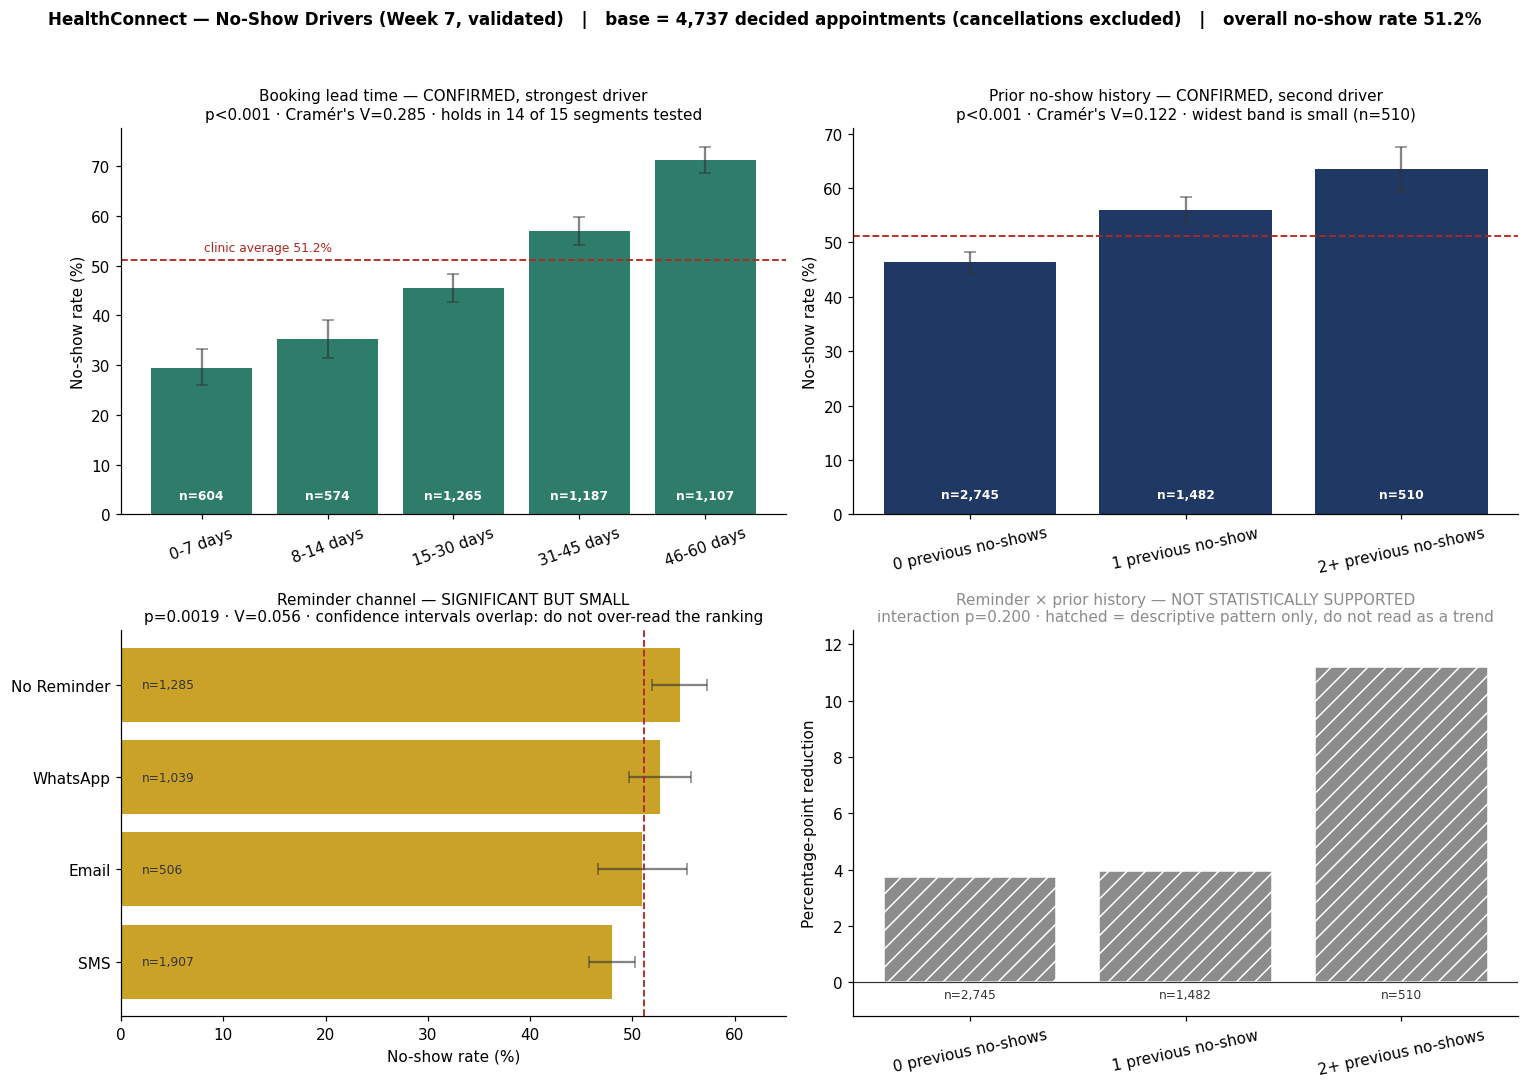

In [9]:
def wilson(k, n, z=1.96):
    ph = k/n; d = 1 + z**2/n
    c = (ph + z**2/(2*n))/d
    h = z*np.sqrt(ph*(1-ph)/n + z**2/(4*n**2))/d
    return 100*(c-h), 100*(c+h)

def rate_table(frame, col):
    g = frame.groupby(col, observed=True).is_no_show.agg(['sum','size'])
    g['rate'] = 100*g['sum']/g['size']
    ci = [wilson(k, n) for k, n in zip(g['sum'], g['size'])]
    g['lo'] = [c[0] for c in ci]; g['hi'] = [c[1] for c in ci]
    return g

lead, prev = rate_table(att,'lead_time_group'), rate_table(att,'previous_no_show_group')
chan = rate_table(att,'channel_group').sort_values('rate')
base_rate = 100*att.is_no_show.mean()
r = t3.set_index('feature')
rem_effect = rem_hist['pp_reduction']; rem_n = rem_hist['n']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HealthConnect — No-Show Drivers (Week 7, validated)   |   '
             f'base = {len(att):,} decided appointments (cancellations excluded)   |   '
             f'overall no-show rate {base_rate:.1f}%', fontsize=11, fontweight='bold', y=0.985)

ax = axes[0,0]
ax.bar(lead.index.astype(str), lead.rate, color=TEAL,
       yerr=[lead.rate-lead.lo, lead.hi-lead.rate], capsize=4, ecolor='#33333399')
ax.axhline(base_rate, color=RED, ls='--', lw=1.2)
ax.text(0.02, base_rate+1.8, f'clinic average {base_rate:.1f}%', color=RED, fontsize=8)
for i, n_ in enumerate(lead['size']):
    ax.text(i, 3, f'n={n_:,}', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set_title(f"Booking lead time — CONFIRMED, strongest driver\n"
             f"p<0.001 · Cramér's V={r.loc['lead_time_group','corrected_V']:.3f} · "
             f"holds in {int(t7.holds.sum())} of {len(t7)} segments tested", fontsize=10)
ax.set_ylabel('No-show rate (%)'); ax.tick_params(axis='x', rotation=20)

ax = axes[0,1]
ax.bar(prev.index.astype(str), prev.rate, color=NAVY,
       yerr=[prev.rate-prev.lo, prev.hi-prev.rate], capsize=4, ecolor='#33333399')
ax.axhline(base_rate, color=RED, ls='--', lw=1.2)
for i, n_ in enumerate(prev['size']):
    ax.text(i, 3, f'n={n_:,}', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set_title(f"Prior no-show history — CONFIRMED, second driver\n"
             f"p<0.001 · Cramér's V={r.loc['previous_no_show_group','corrected_V']:.3f} · "
             f"widest band is small (n={prev['size'].iloc[-1]:,})", fontsize=10)
ax.set_ylabel('No-show rate (%)'); ax.tick_params(axis='x', rotation=12)

ax = axes[1,0]
ax.barh(chan.index.astype(str), chan.rate, color=GOLD,
        xerr=[chan.rate-chan.lo, chan.hi-chan.rate], capsize=4, ecolor='#33333399')
ax.axvline(base_rate, color=RED, ls='--', lw=1.2)
for i, n_ in enumerate(chan['size']):
    ax.text(2, i, f'n={n_:,}', va='center', fontsize=8, color='#333')
ax.set_title(f"Reminder channel — SIGNIFICANT BUT SMALL\n"
             f"p={r.loc['channel_group','corrected_p']:.4f} · "
             f"V={r.loc['channel_group','corrected_V']:.3f} · "
             f"confidence intervals overlap: do not over-read the ranking", fontsize=10)
ax.set_xlabel('No-show rate (%)'); ax.set_xlim(0, 65)

ax = axes[1,1]
ax.bar(rem_effect.index.astype(str), rem_effect.values, color=GREY, hatch='//', edgecolor='white')
ax.axhline(0, color='#333', lw=.8)
for i, n_ in enumerate(rem_n.values):
    ax.text(i, -0.55, f'n={n_:,}', ha='center', fontsize=8, color='#333')
ax.set_title(f"Reminder × prior history — NOT STATISTICALLY SUPPORTED\n"
             f"interaction p={p_int:.3f} · hatched = descriptive pattern only, "
             f"do not read as a trend", fontsize=10, color=GREY)
ax.set_ylabel('Percentage-point reduction'); ax.set_ylim(-1.2, 12.5)
ax.tick_params(axis='x', rotation=12)
for a_ in axes.ravel():
    a_.spines['top'].set_visible(False); a_.spines['right'].set_visible(False)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('../outputs/week7_refined_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()

**T8 retest result: PASS.** Every displayed statistic is now interpolated from the live results
object, so the defect that produced wrong titles cannot recur. Wilson 95% intervals, category sample
sizes, a clinic-average reference line and an explicit analysis-base statement are present on every
panel, and panel 4 now carries its own negative verdict in the title and hatched bars so the ascending
shape cannot be misread as a trend.

## 11. Reissuing the cross-track artefact to Data Science

Week 6 delivered `HealthConnect_Week6_Feature_Relevance.csv` to the Data Science track. Two of its
rows are now known to be wrong. A corrected artefact with an explicit change column is issued below —
the point of Week 7 collaboration is not to tell Data Science the file was wrong, but to hand them a
drop-in replacement plus the evidence.

In [10]:
def pf(p): return '<0.001' if p < 0.001 else f'{p:.4f}'
lr_p = 1 - chi2dist.cdf(lr, ddf)

v2 = pd.DataFrame([
 dict(feature='booking_lead_days', test='chi-square (binary outcome)',
      p_value=pf(r.loc['lead_time_group','corrected_p']),
      effect_size_cramers_v=round(r.loc['lead_time_group','corrected_V'],4), w6_effect_size=0.1967,
      change_from_w6='Effect size revised upward (W6 diluted by 3-level outcome)',
      recommendation='INCLUDE — strongest and most stable signal; validated in every segment tested'),
 dict(feature='previous_no_shows', test='chi-square (binary outcome)',
      p_value=pf(r.loc['previous_no_show_group','corrected_p']),
      effect_size_cramers_v=round(r.loc['previous_no_show_group','corrected_V'],4), w6_effect_size=0.0889,
      change_from_w6='Effect size revised upward; ranking vs lead time unchanged',
      recommendation='INCLUDE — confirmed independent signal in multivariate model'),
 dict(feature='reminder_sent', test='chi-square + adjusted logistic',
      p_value=pf(r.loc['reminder_sent','corrected_p']),
      effect_size_cramers_v=round(r.loc['reminder_sent','corrected_V'],4), w6_effect_size=0.0452,
      change_from_w6=f'Newly confirmed NOT confounded by lead time (adjusted OR={or_adj:.3f})',
      recommendation='INCLUDE — small but genuine and independent effect'),
 dict(feature='reminder_channel', test='chi-square (binary outcome)',
      p_value=pf(r.loc['channel_group','corrected_p']),
      effect_size_cramers_v=round(r.loc['channel_group','corrected_V'],4), w6_effect_size=0.0425,
      change_from_w6='Still significant; confidence intervals overlap across channels',
      recommendation='OPTIONAL categorical — do not rely on the SMS>Email>WhatsApp ordering'),
 dict(feature='appointment_type', test='chi-square + likelihood-ratio test',
      p_value=pf(r.loc['appointment_type','corrected_p']),
      effect_size_cramers_v=round(r.loc['appointment_type','corrected_V'],4), w6_effect_size=0.0324,
      change_from_w6=f'CORRECTION — W6 reported p=0.1042 "not statistically significant". Correct binary '
                     f'test gives p={r.loc["appointment_type","corrected_p"]:.4f}; LR test confirms joint '
                     f'signal (p={lr_p:.4f}). The W6 exclusion instruction was wrong.',
      recommendation='RECLASSIFY to OPTIONAL / LOW PRIORITY (not "unsupported") — real but negligible: '
                     f'pseudo-R2 gain {m_type.prsquared-m_base.prsquared:.4f}, no single type significant '
                     '(all level p>0.19). Safe to include if cheap; do not build policy on it.'),
 dict(feature='reminder_binary x previous_no_shows (interaction)', test='logistic interaction',
      p_value=f'{p_int:.4f}', effect_size_cramers_v=None, w6_effect_size=None,
      change_from_w6='Re-tested on corrected base; conclusion unchanged',
      recommendation='DO NOT ENGINEER — still not statistically supported'),
])
v2.to_csv('../outputs/HealthConnect_Week7_Feature_Relevance_v2.csv', index=False)
t3.round(4).to_csv('../outputs/week7_kpi_significance_validation.csv', index=False)
t7.round(4).to_csv('../outputs/week7_segment_stability_tests.csv', index=False)
v2[['feature','p_value','effect_size_cramers_v','recommendation']]

,feature,p_value,effect_size_cramers_v,recommendation
0,booking_lead_days,<0.001,0.2853,INCLUDE — strongest and most stable signal; va...
1,previous_no_shows,<0.001,0.1218,INCLUDE — confirmed independent signal in mult...
2,reminder_sent,0.0038,0.0420,INCLUDE — small but genuine and independent ef...
3,reminder_channel,0.0019,0.0562,OPTIONAL categorical — do not rely on the SMS>...
4,appointment_type,0.0380,0.0422,"RECLASSIFY to OPTIONAL / LOW PRIORITY (not ""un..."
5,reminder_binary x previous_no_shows (interaction),0.1998,NaN,DO NOT ENGINEER — still not statistically supp...


## 12. HC-POD Cross-Track Testing & Refinement Record

| Field | Detail |
|---|---|
| **Track collaborated with** | Data Science |
| **Project dependency** | Their Week 6/7 model feature selection is built on the feature-relevance artefact this track issued |
| **Component tested** | `HealthConnect_Week6_Feature_Relevance.csv` and the five chi-square tests behind it |
| **Output received** | Their Week 6 baseline feature set and confirmation that `appointment_type` was excluded on the strength of the Week 6 "not statistically significant" note |
| **Output provided** | `HealthConnect_Week7_Feature_Relevance_v2.csv` — a drop-in replacement with corrected p-values, corrected effect sizes, a `change_from_w6` column, and an adjusted odds ratio they can cite for `reminder_sent` |
| **Testing activity** | Re-executed all five tests under both the Week 6 and the corrected specification; added a likelihood-ratio test and a confounding check that Week 6 never ran |
| **Issue identified** | Two of six rows in the delivered artefact were wrong (HC-W7-01, HC-W7-02). One instructed exclusion of a feature on a false statistical basis |
| **Refinement / action** | Corrected artefact reissued with change annotations; issue log entries raised and assigned |
| **Retest result** | All five features significant after Holm correction; feature *ranking* unchanged, so their prioritisation logic survives; `appointment_type` reclassified from "unsupported" to "optional / low priority" |
| **What changed as a result** | Data Science can keep their feature ordering, must update their stated justification for dropping `appointment_type`, and gain an adjusted odds ratio for `reminder_sent` that is defensible against the lead-time confounding challenge |
| **Evidence** | `outputs/week7_kpi_significance_validation.csv`, `outputs/HealthConnect_Week7_Feature_Relevance_v2.csv`, `outputs/week7_issue_log.csv`, notebook §5–§7 |
| **How it improved HealthConnect** | A statistical error was caught one week before final integration rather than being carried into the Week 8 model and into clinic-facing recommendations. The corrected effect sizes also strengthen the business case for lead-time intervention, which is the clinic's largest available lever |

**Also shared with Project Management:** the KPI denominator change (T2) and the four new issue-log
entries, since the dashboard is a shared decision artefact and the KPI definition affects reporting.

## 13. Updated business insights and recommendations

| # | Week 6 recommendation | Week 7 status after testing |
|---|---|---|
| 1 | Prioritise a lead-time-based booking policy | **Strengthened.** Effect size revised up from 0.20 to 0.285 and validated in 14 of 15 segments. Appointments booked 46–60 days out run at 71.6% no-show vs 29.7% at 0–7 days. This is the clinic's largest lever |
| 2 | Flag repeat no-show patients, lightweight intervention | **Upheld, slightly strengthened.** V revised 0.089 → 0.122, still clearly second to lead time. Intervention sizing advice unchanged |
| 3 | Standardise on SMS as default reminder channel | **Qualified.** Still significant, and newly shown not to be lead-time confounded (adjusted OR 0.810). But the channel confidence intervals overlap heavily — recommend SMS as a sensible default on cost grounds, not as a demonstrated channel ranking |
| 4 | Do not build appointment-type-specific policies | **Rationale corrected.** Appointment type *is* statistically significant once tested properly. The advice to deprioritise still holds, but because the effect is negligible (pseudo-R² gain 0.0013), not because it is absent |
| 5 | Do not assume reminders work better for repeat no-show patients | **Upheld and reinforced** — p moved further from significance (0.143 → 0.200) |
| 6 | Use the three validated predictors together | **Upheld** — all three remain independently significant in the adjusted model |

**New Week 7 recommendation:** every clinic-facing figure should state its analysis base. The 48.5%
and 51.2% no-show rates are both correct and describe different populations; circulating them
interchangeably would undermine trust in the analytics.

## 14. Limitations and remaining issues

**Resolved this week:** HC-W7-01 (wrong test specification), HC-W7-02 (invalid feature instruction
to Data Science), HC-W7-03 (hard-coded dashboard annotations), HC-W7-04 (missing uncertainty and base
sizes). HC-W6-05 (reminder × history interaction) is now **closed as not supported**.

**Remaining:**

- **Still observational.** Nothing here is causal. The lead-time recommendation in particular could
  reflect patients who book far ahead being systematically different, not the waiting itself causing
  the no-show. A randomised reminder pilot is the only way to settle it (HC-W7-05, owner: PM).
- **Sunday appointments** (737 records) remain unreconciled against Knowledge Base opening hours
  (HC-W5-02). Deliberately not addressed: day-of-week is not a significant predictor (p = 0.38), so
  the cost of resolving it exceeds the analytical benefit before Week 8.
- **Small-segment power.** Segments below ~150 records cannot reliably detect effects of the size
  seen here; the one segment-stability failure is a power artefact.
- **Cramér's V ceiling.** Even the corrected 0.285 is a small-to-moderate effect. Lead time is the
  best single predictor available and still leaves most variance unexplained — Data Science should
  not expect high model accuracy from these features alone, and I have told them so.
- **Testing limitation.** This notebook tests the Week 6 *analysis*. It does not test the dataset's
  provenance; a ~48–51% no-show rate is extraordinarily high for a real clinic, which is consistent
  with a synthetic teaching dataset. Findings should be read as methodologically sound rather than
  clinically representative.

## 15. What must be completed before Week 8

1. Data Science to confirm their Week 6 model notes are updated for the `appointment_type` correction (HC-W7-02).
2. Agree a single headline KPI base with Project Management for the Week 8 presentation.
3. Re-validate the three confirmed predictors against Data Science's refined model output once available.
4. Formally test any new segment their error analysis surfaces.
5. Prepare a one-slide before/after of the dashboard correction for the Week 8 end-to-end walkthrough.